<span><a href="https://colab.research.google.com/github/gse-unil/2026_Geoinformatique_II/blob/main/tps/python/tp-py03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a> <a href="https://www.kaggle.com/kernels/welcome?src=https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/tps/python/tp-py03.ipynb" target="_parent"><img src="https://img.shields.io/badge/Open%20in-Kaggle-20BEFF?logo=kaggle&logoColor=white" alt="Open in Kaggle"/></a> <a href="https://renkulab.io/p/fatihi.ayb/geoinformatique-ii/" target="_parent"><img src="https://renkulab.io/renku-badge.svg" alt="Launch on Renku"/></a></span>

> **Exécution dans le cloud** : ce notebook peut aussi tourner dans le cloud (Colab, Kaggle, Renku).
> Avant de lancer les cellules, télécharge `tp3.gpkg` et `meuse.csv` depuis le dossier OneDrive du cours et dépose-les dans le répertoire de travail du notebook (Colab : panneau 📁 → *Upload* ; Kaggle : *File → Upload* ; Renku : déjà dans le projet).
> Procédure complète : [docs/cloud-badges.md](https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/docs/cloud-badges.md).


# TP Python 3 : Géotraitement vectoriel & modèles non-linéaires

Ce TP Python est le pendant numérique du **TP QGIS 3**. Tu vas reproduire les mêmes opérations de géotraitement vectoriel en Python, puis appliquer des modèles de régression non-linéaires sur des données géographiques historiques.

| Partie | Bibliothèque | Ce que tu apprendras |
|--------|-------------|----------------------|
| 1. Sélection & extraction | `geopandas` | Sélectionner des entités par attribut, dissoudre, découper |
| 2. Zones tampons | `geopandas` / `shapely` | Créer des buffers, définir la zone urbaine (ZDB, ZU) |
| 3. Superposition | `geopandas` / `shapely` | Union, différence, intersection → WUI |
| 4. GAM | `statsmodels` / `sklearn` | Modèles additifs généralisés, splines, lisseur spatial, validation croisée |

> 🔗 **Lien avec le TP QGIS 3** : les parties 1–3 reproduisent en Python le même résultat que dans QGIS —
> la zone d'interface habitat-forêt (WUI) du district bernois de _Frutigen-Niedersimmental_.
> La partie 4 modélise la pollution des sols (jeu **Meuse**, Pays-Bas) : régression
> polynomiale, GLM et GAM avec lisseur spatial, pour prédire la concentration en zinc à
> partir de variables de terrain et de la position géographique.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from rasterio.features import rasterize

from scipy.ndimage import distance_transform_edt

import geopandas as gpd

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, mean_absolute_error, r2_score)


In [3]:
# -------------------------------------------------------
# Chargement des données vectorielles depuis tp3.gpkg
# -------------------------------------------------------
GPKG_PATH = "tp3.gpkg"
CRS_REF   = 'EPSG:21781'   # CH1903 / LV03

foret     = gpd.read_file(GPKG_PATH, layer='Foret').to_crs(CRS_REF)
buildings = gpd.read_file(GPKG_PATH, layer='Buildings').to_crs(CRS_REF)
roads     = gpd.read_file(GPKG_PATH, layer='Roads').to_crs(CRS_REF)
communes  = gpd.read_file(GPKG_PATH, layer='Communes').to_crs(CRS_REF)
districts = gpd.read_file(GPKG_PATH, layer='districts').to_crs(CRS_REF)

print("Couches vectorielles chargées depuis tp3.gpkg :")
for name, gdf in [
    ('Foret',     foret),
    ('Buildings', buildings),
    ('Roads',     roads),
    ('Communes',  communes),
    ('Districts', districts),
]:
    geom_type = gdf.geometry.geom_type.iloc[0]
    print(f"  {name:12s}: {len(gdf):7d} entités | CRS: EPSG:{gdf.crs.to_epsg()} | géométrie: {geom_type}")


Couches vectorielles chargées depuis tp3.gpkg :
  Foret       :   13461 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Buildings   :  373399 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Roads       :  112567 entités | CRS: EPSG:21781 | géométrie: MultiLineString
  Communes    :    8868 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Districts   :     234 entités | CRS: EPSG:21781 | géométrie: MultiPolygon


---
## Partie 1 — Sélection et extraction

Dans le TP QGIS 3, nous avons commencé par sélectionner les districts bernois de
_Frutigen-Niedersimmental_ et _Obersimmental-Saanen_, les avons fusionnés pour
définir le périmètre d'étude, puis avons découpé les autres couches dans ce périmètre.

En Python avec **geopandas**, les équivalents sont :

| Outil QGIS | Équivalent Python |
|---|---|
| Sélection par expression | `gdf[gdf['col'].str.contains(...)]` |
| Fusionner les entités | `gdf.dissolve()` |
| Couper (*Clip*) | `gpd.clip(layer, mask)` |

### 1.1 Sélection des districts et fusion (étapes 2a/2b)


On sélectionne les districts par expression (équivalent du filtre SQL `"NAME" ILIKE '...'`
dans QGIS), puis on les fusionne en une seule entité (`dissolve`) pour
définir le périmètre global de la zone d'étude.


Districts sélectionnés (2) :
  • Frutigen-Niedersimmental
  • Obersimmental-Saanen

Zone d'étude fusionnée : 1 polygone
  Aire totale  : 1349.1 km²
  Périmètre    : 205.5 km


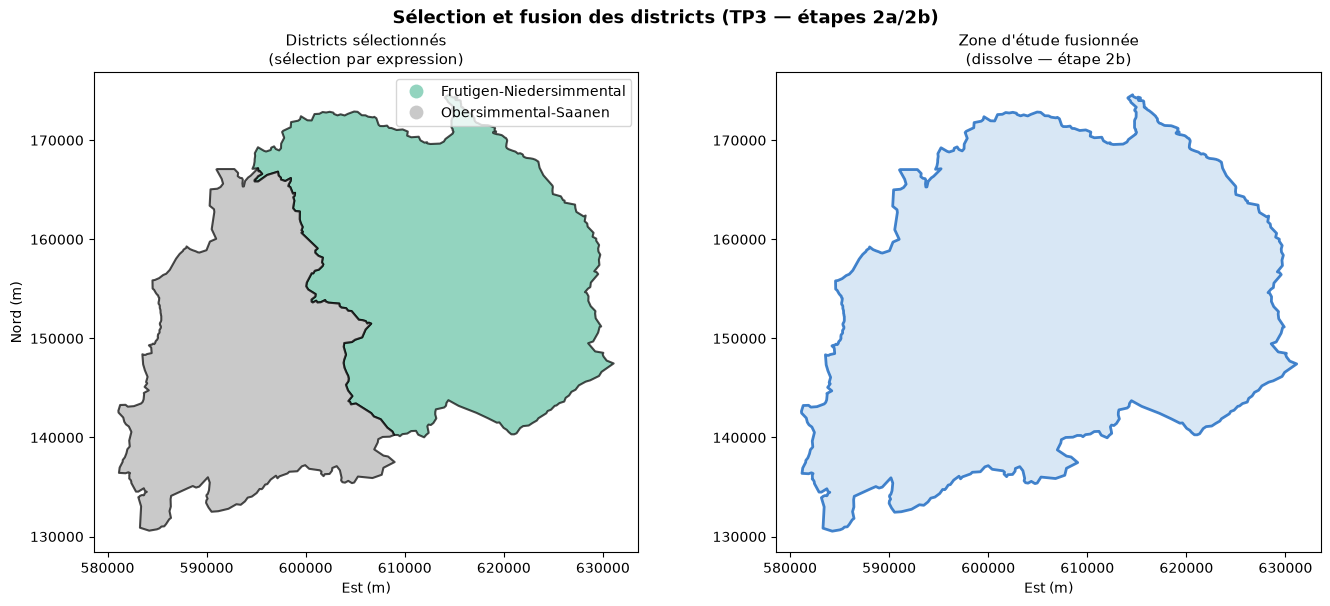

In [4]:
# -------------------------------------------------------
# 2a — Sélection par expression (= filtre SQL dans QGIS)
# -------------------------------------------------------
study_districts = districts[
    districts['NAME'].str.contains(
        'Frutigen-Niedersimmental|Obersimmental-Saanen',
        case=False, na=False
    )
].copy()

print(f"Districts sélectionnés ({len(study_districts)}) :")
for _, row in study_districts.iterrows():
    print(f"  • {row['NAME']}")

# -------------------------------------------------------
# 2b — Fusionner les entités (= dissolve / Fusionner dans QGIS)
# -------------------------------------------------------
study_area = study_districts.dissolve().reset_index(drop=True)[['geometry']]

print(f"\nZone d'étude fusionnée : 1 polygone")
print(f"  Aire totale  : {study_area.geometry.area.iloc[0] / 1e6:.1f} km²")
print(f"  Périmètre    : {study_area.geometry.length.iloc[0] / 1e3:.1f} km")

# -------------------------------------------------------
# Visualisation
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

study_districts.plot(ax=axes[0], column='NAME', cmap='Set2',
                     edgecolor='black', linewidth=1.5, alpha=0.7, legend=True)
axes[0].set_title('Districts sélectionnés\n(sélection par expression)', fontsize=11)
axes[0].set_xlabel('Est (m)')
axes[0].set_ylabel('Nord (m)')

study_area.plot(ax=axes[1], facecolor='#cfe2f3', edgecolor='#1565c0',
                linewidth=2, alpha=0.8)
axes[1].set_title('Zone d\'étude fusionnée\n(dissolve — étape 2b)', fontsize=11)
axes[1].set_xlabel('Est (m)')

plt.suptitle('Sélection et fusion des districts (TP3 — étapes 2a/2b)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.2 Découpage des couches (étape 2c)

Une fois le périmètre défini, on découpe toutes les couches avec `gpd.clip()`,
l'équivalent de l'outil Couper (*Clip*) dans QGIS.
Cela garantit que les géotraitements suivants ne portent que sur la zone d'étude.


Découpage des couches à la zone d'étude...

Résultat du découpage :
  Forêt       :    409 entités
  Bâtiments   :   2680 entités
  Routes      :    806 entités
  Communes    :     48 entités


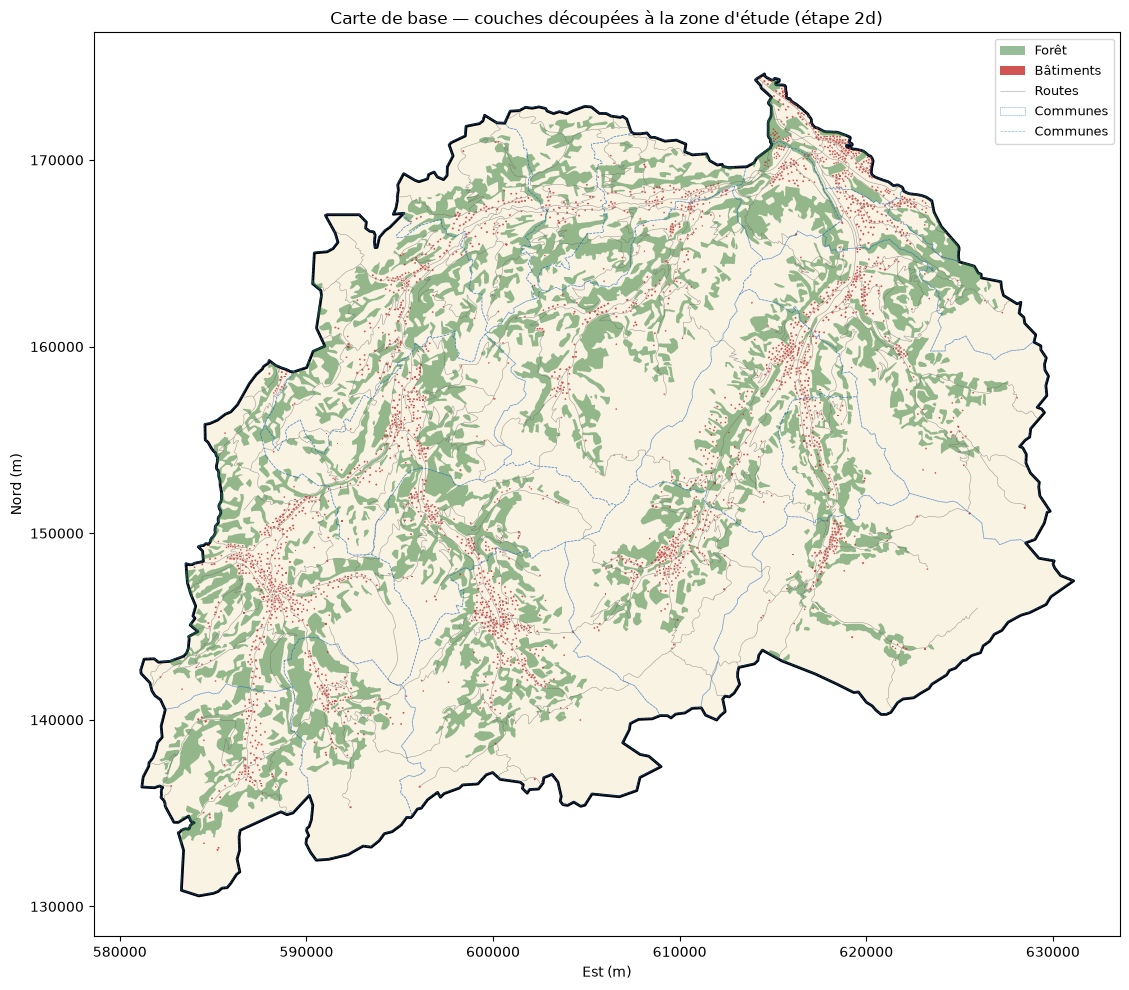

In [5]:
# -------------------------------------------------------
# 2c — Découpage (= outil Clip dans QGIS)
# -------------------------------------------------------
print("Découpage des couches à la zone d'étude...")

foret_clip     = gpd.clip(foret,     study_area).reset_index(drop=True)
buildings_clip = gpd.clip(buildings, study_area).reset_index(drop=True)
roads_clip     = gpd.clip(roads,     study_area).reset_index(drop=True)
communes_clip  = gpd.clip(communes,  study_area).reset_index(drop=True)

print("\nRésultat du découpage :")
for name, gdf in [
    ('Forêt',      foret_clip),
    ('Bâtiments',  buildings_clip),
    ('Routes',     roads_clip),
    ('Communes',   communes_clip),
]:
    print(f"  {name:12s}: {len(gdf):6d} entités")

# -------------------------------------------------------
# Carte de base découpée (étape 2d dans QGIS)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

study_area.plot(ax=ax, facecolor='#f9f3e3', edgecolor='black', linewidth=2, zorder=1)
foret_clip.plot(ax=ax, color='#2e7d32', alpha=0.5, label='Forêt', zorder=2)
buildings_clip.plot(ax=ax, color='#c62828', alpha=0.8, markersize=0.3,
                    label='Bâtiments', zorder=3)
roads_clip.plot(ax=ax, color='#616161', linewidth=0.4, alpha=0.6,
                label='Routes', zorder=4)
communes_clip.plot(ax=ax, facecolor='none', edgecolor='#1565c0',
                   linewidth=0.5, linestyle='--', alpha=0.5,
                   label='Communes', zorder=5)

ax.set_title('Carte de base — couches découpées à la zone d\'étude (étape 2d)', fontsize=12)
ax.set_xlabel('Est (m)')
ax.set_ylabel('Nord (m)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


---
## Partie 2 — Zones tampons (Buffer)

Les zones tampons permettent de définir des zones de proximité autour d'entités.
Dans QGIS, nous avons utilisé l'outil Zone tampon pour :

1. Zone Densément Bâtie (ZDB) — buffer `+75 m` sur les bâtiments (regroupé),
   puis buffer `−75 m` pour conserver uniquement les zones densément bâties
2. Emprise des routes — buffer de `6 m` (= moitié de la largeur de 12 m)

| Outil QGIS | Équivalent Python |
|---|---|
| Zone tampon (Buffer) | `.buffer(distance)` sur `geometry` |
| Regrouper le résultat | `.unary_union` (fusionne en une seule géométrie) |

### 2.1 ZDB — Zone Densément Bâtie (étape 3a)


Étape 1 : buffer +75 m sur les bâtiments (regroupé)...
Étape 2 : buffer −75 m pour garder uniquement les zones denses (ZDB)...
  ZDB : aire totale = 32.30 km²

Buffer routes (6 m)...
  Routes bufferisées : aire = 15.05 km²


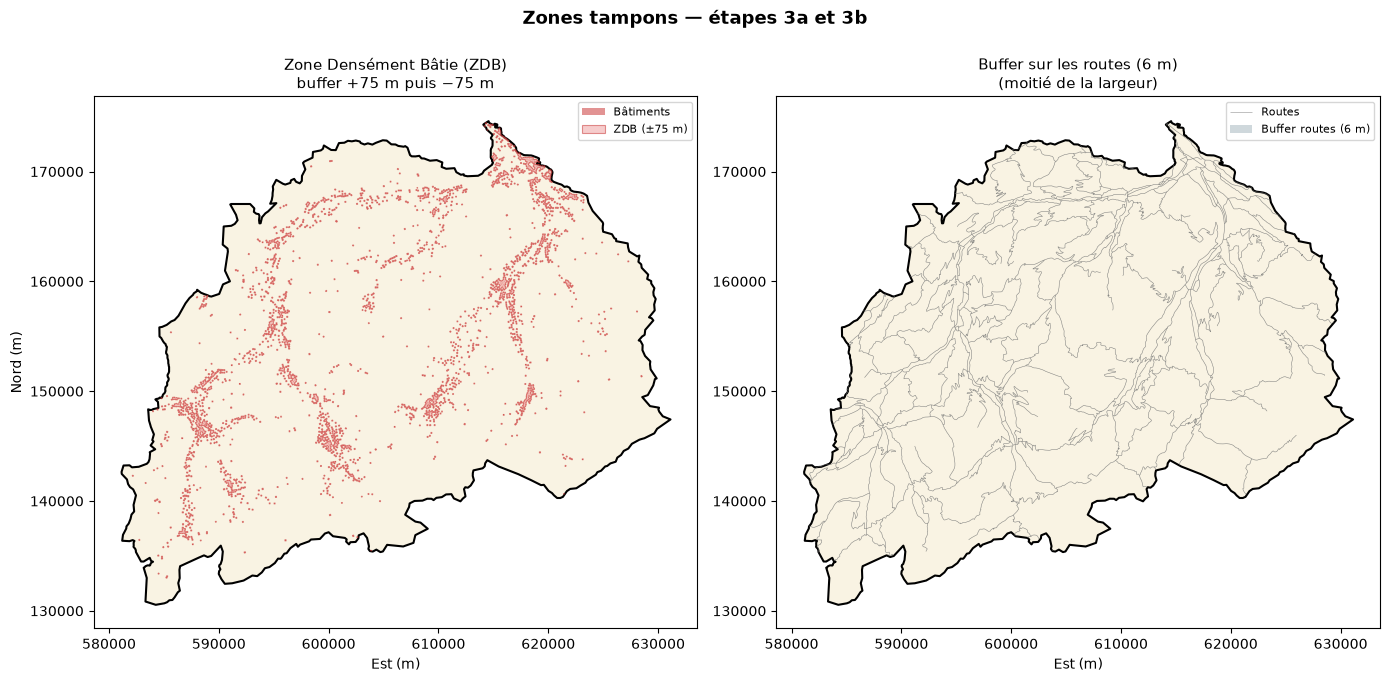

In [6]:
# -------------------------------------------------------
# 3a — Zone Densément Bâtie (ZDB)
#   Étape 1 : buffer +75 m sur les bâtiments, regroupé (unary_union)
#   Étape 2 : buffer −75 m pour éliminer les zones peu denses
# -------------------------------------------------------
print("Étape 1 : buffer +75 m sur les bâtiments (regroupé)...")
buf_pos = buildings_clip.geometry.buffer(75).union_all()   # buffer + dissolve

print("Étape 2 : buffer −75 m pour garder uniquement les zones denses (ZDB)...")
zdb_geom = buf_pos.buffer(-75)
zdb = gpd.GeoDataFrame(geometry=[zdb_geom], crs=CRS_REF)
print(f"  ZDB : aire totale = {zdb_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 3b — Buffer routes (6 m = moitié de la largeur totale de 12 m)
# -------------------------------------------------------
print("\nBuffer routes (6 m)...")
roads_buf_geom = roads_clip.geometry.buffer(6).union_all()
roads_buf = gpd.GeoDataFrame(geometry=[roads_buf_geom], crs=CRS_REF)
print(f"  Routes bufferisées : aire = {roads_buf_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# Visualisation
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

study_area.plot(ax=axes[0], facecolor='#f9f3e3', edgecolor='black', linewidth=1.5)
buildings_clip.plot(ax=axes[0], color='#c62828', alpha=0.5, markersize=0.5,
                    label='Bâtiments')
zdb.plot(ax=axes[0], facecolor='#ef9a9a', edgecolor='#c62828',
         linewidth=0.8, alpha=0.5, label='ZDB (±75 m)')
axes[0].set_title('Zone Densément Bâtie (ZDB)\nbuffer +75 m puis −75 m', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Est (m)')
axes[0].set_ylabel('Nord (m)')

study_area.plot(ax=axes[1], facecolor='#f9f3e3', edgecolor='black', linewidth=1.5)
roads_clip.plot(ax=axes[1], color='#616161', linewidth=0.4, alpha=0.7,
                label='Routes')
roads_buf.plot(ax=axes[1], facecolor='#b0bec5', edgecolor='none',
               alpha=0.6, label='Buffer routes (6 m)')
axes[1].set_title('Buffer sur les routes (6 m)\n(moitié de la largeur)', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Est (m)')

plt.suptitle('Zones tampons — étapes 3a et 3b', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Partie 3 — Superposition (Union, Différence, Intersection)

Ces outils permettent de combiner plusieurs couches pour créer de nouvelles entités.
C'est l'étape centrale du TP pour produire la **WUI** (Wildland-Urban Interface).

| Outil QGIS | Équivalent Python (shapely) |
|---|---|
| Union | `geom_a.union(geom_b)` |
| Différence | `geom_a.difference(geom_b)` |
| Intersection | `geom_a.intersection(geom_b)` |

### 3.1 Zone Urbaine (ZU) = ZDB ∪ routes (étape 4a)
### 3.2 Zone à risque = Buffer(ZU, 80 m) − ZU (étape 4b)
### 3.3 WUI = zone à risque ∩ Forêt (étape 4c)


4a — Union : ZDB ∪ routes bufferisées → Zone Urbaine (ZU)...
  Zone Urbaine (ZU) : aire = 46.66 km²
4b — Buffer 80 m + Différence → zone de risque incendie...
  Zone à risque (bande 80 m hors ZU) : aire = 233.50 km²
4c — Intersection zone risque ∩ Forêt → WUI...
  WUI : aire = 46.21 km²
  WUI représente 15.5 % de la surface forestière


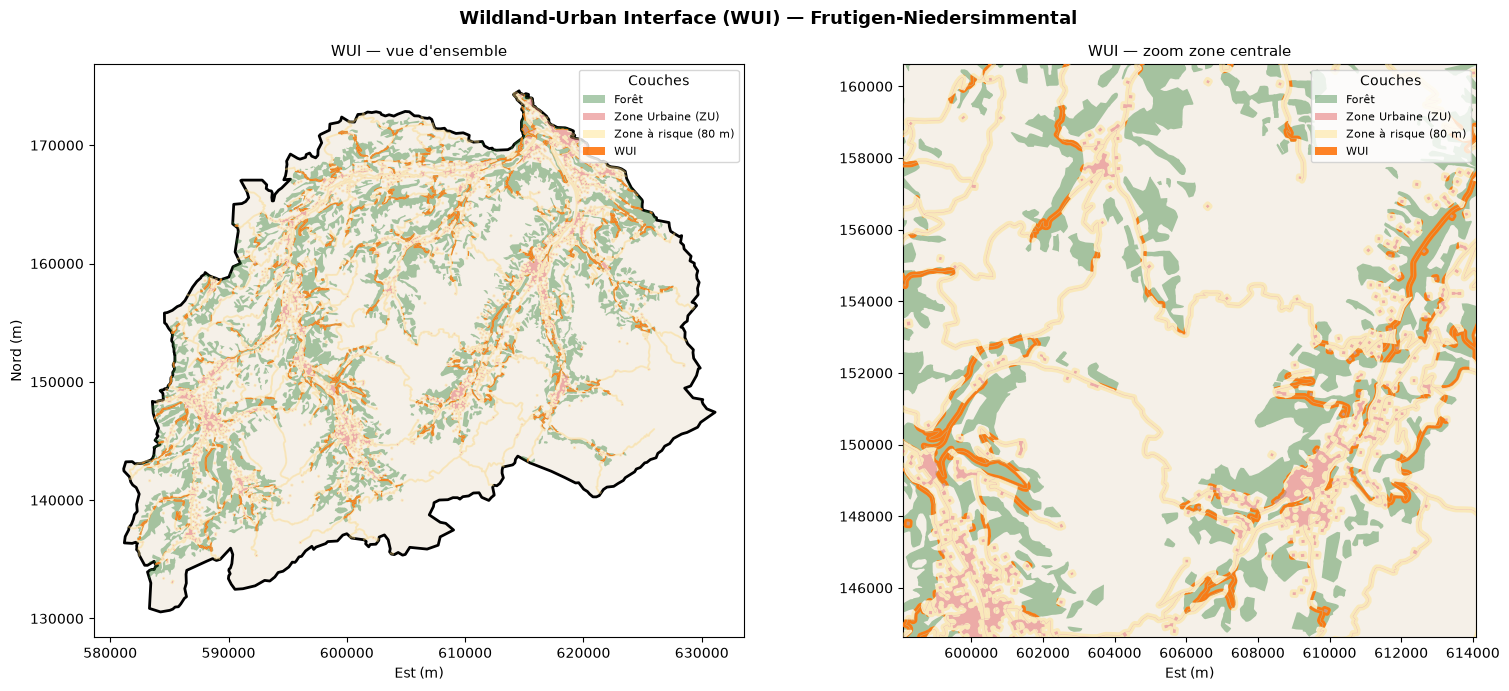

In [7]:
# -------------------------------------------------------
# 4a — Union ZDB ∪ routes bufferisées → Zone Urbaine (ZU)
# -------------------------------------------------------
print("4a — Union : ZDB ∪ routes bufferisées → Zone Urbaine (ZU)...")
zu_geom = zdb_geom.union(roads_buf_geom)
zu = gpd.GeoDataFrame(geometry=[zu_geom], crs=CRS_REF)
print(f"  Zone Urbaine (ZU) : aire = {zu_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 4b — Buffer 80 m autour de ZU + Différence → zone de risque incendie
# -------------------------------------------------------
print("4b — Buffer 80 m + Différence → zone de risque incendie...")
zu_buf_80 = zu_geom.buffer(80)
zone_risque_geom = zu_buf_80.difference(zu_geom)
zone_risque = gpd.GeoDataFrame(geometry=[zone_risque_geom], crs=CRS_REF)
print(f"  Zone à risque (bande 80 m hors ZU) : aire = {zone_risque_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 4c — Intersection zone risque ∩ Forêt → WUI
# -------------------------------------------------------
print("4c — Intersection zone risque ∩ Forêt → WUI...")
foret_union = foret_clip.geometry.union_all()
wui_geom = zone_risque_geom.intersection(foret_union)
wui = gpd.GeoDataFrame(geometry=[wui_geom], crs=CRS_REF)
print(f"  WUI : aire = {wui_geom.area / 1e6:.2f} km²")
print(f"  WUI représente {wui_geom.area / foret_union.area * 100:.1f} % de la surface forestière")

# -------------------------------------------------------
# Carte finale — WUI (vue d'ensemble + zoom)
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax in axes:
    study_area.plot(ax=ax, facecolor='#f5f0e8', edgecolor='black', linewidth=2, zorder=1)
    foret_clip.plot(ax=ax, color='#2e7d32', alpha=0.4, label='Forêt', zorder=2)
    zu.plot(ax=ax, facecolor='#e57373', edgecolor='none', alpha=0.55,
            label='Zone Urbaine (ZU)', zorder=3)
    zone_risque.plot(ax=ax, facecolor='#ffe082', edgecolor='none', alpha=0.45,
                     label='Zone à risque (80 m)', zorder=4)
    wui.plot(ax=ax, facecolor='#ff6d00', edgecolor='none', alpha=0.85,
             label='WUI', zorder=5)

axes[0].set_title('WUI — vue d\'ensemble', fontsize=11)
axes[0].set_xlabel('Est (m)'); axes[0].set_ylabel('Nord (m)')
axes[0].legend(loc='upper right', fontsize=8, title='Couches')

# Zoom au centre pour mieux voir le WUI
b = study_area.total_bounds
cx, cy = (b[0]+b[2])/2, (b[1]+b[3])/2
zoom = 8000
axes[1].set_xlim(cx - zoom, cx + zoom)
axes[1].set_ylim(cy - zoom, cy + zoom)
axes[1].set_title('WUI — zoom zone centrale', fontsize=11)
axes[1].set_xlabel('Est (m)')
axes[1].legend(loc='upper right', fontsize=8, title='Couches')

plt.suptitle('Wildland-Urban Interface (WUI) — Frutigen-Niedersimmental',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Partie 4 — Régression non-linéaire : polynômes, GLM et GAM

### Pourquoi aller au-delà de la régression linéaire ?

La régression linéaire (OLS) suppose que l'effet de chaque variable explicative est constant et proportionnel, et que la variable cible peut prendre n'importe quelle valeur réelle. Ces deux hypothèses sont souvent trop restrictives pour des données réelles, en particulier géographiques : l'effet d'une variable peut se courber (s'atténuer, s'inverser), et une variable physiquement bornée (une concentration, un pourcentage, un compte) ne se prête pas à une droite qui peut, en théorie, prendre n'importe quelle valeur.

Cette partie relâche ces hypothèses progressivement, en gardant le même jeu de données (Meuse) et la même variable cible (`zinc`) comme fil conducteur :

| Étape | Ce qui change par rapport à OLS | Section |
|---|---|---|
| **Régression polynomiale** | La relation $x \to y$ n'est plus une droite mais un polynôme, reste un modèle linéaire dans ses paramètres | 4.3 |
| **GLM** (*Generalized Linear Model*) | La prédiction est transformée (via un logarithme) pour rester dans une plage valide, ici $> 0$ | 4.4 |
| **GAM** (*Generalized Additive Model*) | Chaque effet $\beta_j x_j$ devient une fonction lisse $f_j(x_j)$ apprise depuis les données, sans forme paramétrique imposée | 4.5–4.6 |

Ces fonctions lisses (GAM) sont approximées par des B-splines (polynômes par morceaux raccordés) avec une pénalité de lissage pour éviter le surapprentissage.

### Les données : la Meuse (pollution des sols, Pays-Bas)

Le jeu **Meuse** est un classique de la géostatistique : 155 sites de sol échantillonnés dans la plaine inondable de la rivière Meuse, près de Stein (Pays-Bas). Deux sites n'ont pas de mesure de matière organique et sont écartés : 153 sites sont utilisés pour la modélisation. Les crues déposent des sédiments chargés en métaux lourds ; on mesure notamment la concentration en zinc.

| Variable | Description |
|---|---|
| **zinc** | Concentration en zinc dans le sol (ppm) ← **variable cible** |
| **dist** | Distance à la rivière (normalisée 0–1) |
| **elev** | Altitude relative du site (m) |
| **om** | Matière organique du sol (%) |
| **x, y** | Coordonnées du site (CRS RD New, EPSG:28992) |

Question : peut-on expliquer la concentration en zinc à partir de ces variables de terrain ? La position géographique (proximité de la rivière, effet des crues) joue-t-elle un rôle propre, au-delà des variables mesurées ?


In [8]:
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)   # ciblé : pas de masquage global

# La Meuse : 155 sites de sol. On charge le CSV et on reconstruit un GeoDataFrame
# (points), avec le système de coordonnées néerlandais RD New (EPSG:28992).
meuse = pd.read_csv('meuse.csv')
meuse = gpd.GeoDataFrame(
    meuse,
    geometry=gpd.points_from_xy(meuse['x'], meuse['y']),
    crs='EPSG:28992',
)

target   = 'zinc'
features = ['dist', 'elev', 'om']
labels   = ['Distance\nrivière', 'Altitude', 'Matière\norganique']

# 2 sites n'ont pas de mesure de matière organique (om). On ne garde que les
# sites aux mesures complètes pour la modélisation (analyse en cas complets).
meuse = meuse.dropna(subset=[target] + features).reset_index(drop=True)

y    = meuse[target].values
X_th = meuse[features].values
X_sp = meuse[features + ['x', 'y']].values

print(f"Meuse : {len(meuse)} sites aux mesures complètes | CRS : {meuse.crs}\n")
print(meuse[[target] + features].describe().round(2).to_string())


Meuse : 153 sites aux mesures complètes | CRS : EPSG:28992

          zinc    dist    elev      om
count   153.00  153.00  153.00  153.00
mean    473.61    0.24    8.16    7.48
std     367.87    0.20    1.06    3.43
min     113.00    0.00    5.18    1.00
25%     198.00    0.08    7.54    5.30
50%     332.00    0.21    8.18    6.90
75%     676.00    0.36    8.97    9.00
max    1839.00    0.88   10.52   17.00


### 4.1 Exploration : carte et corrélations

Avant de modéliser, on visualise la distribution spatiale du zinc et les corrélations entre variables. La carte révèle d'emblée un fort gradient géographique, les concentrations les plus élevées longent la rivière, qui motivera plus loin l'ajout d'un lisseur spatial.


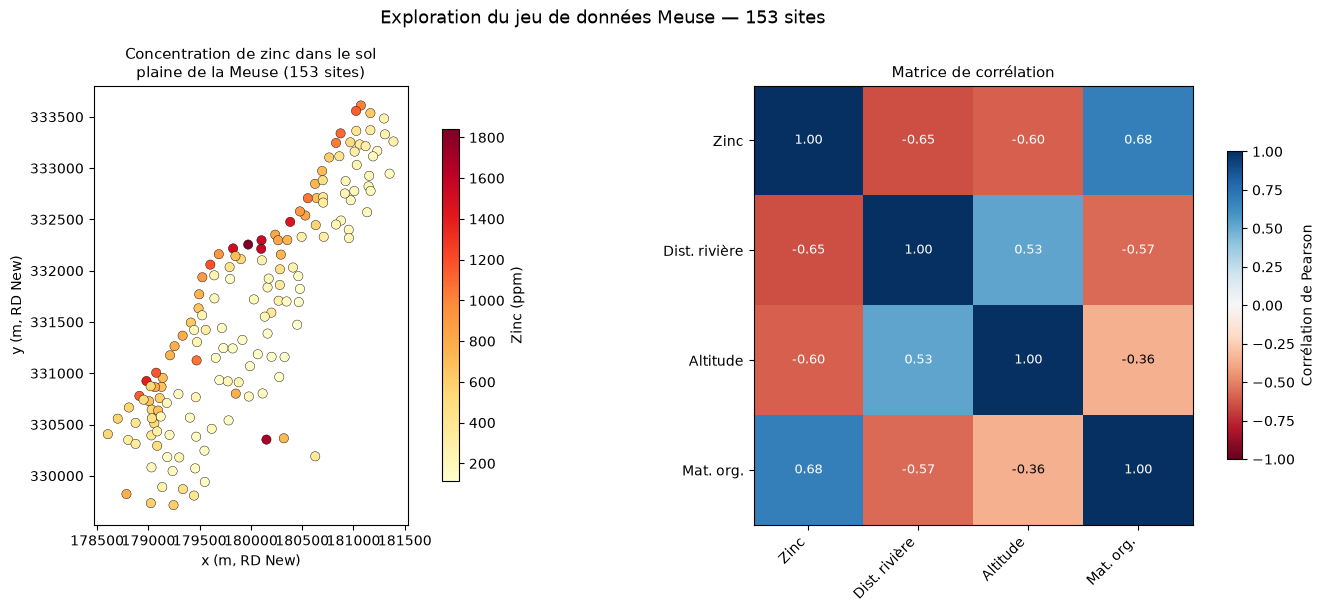

In [9]:
vars_corr = [target] + features
corr = meuse[vars_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Carte : concentration de zinc (points), gradient depuis la rivière
sc = axes[0].scatter(meuse['x'], meuse['y'], c=meuse['zinc'],
                     cmap='YlOrRd', s=45, edgecolor='k', linewidth=0.3)
plt.colorbar(sc, ax=axes[0], label='Zinc (ppm)', shrink=0.8)
axes[0].set_title("Concentration de zinc dans le sol\nplaine de la Meuse (153 sites)", fontsize=11)
axes[0].set_xlabel('x (m, RD New)'); axes[0].set_ylabel('y (m, RD New)')
axes[0].set_aspect('equal')

# Matrice de corrélation
im = axes[1].imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
tick_labels = ['Zinc', 'Dist. rivière', 'Altitude', 'Mat. org.']
axes[1].set_xticks(range(len(vars_corr))); axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')
axes[1].set_yticks(range(len(vars_corr))); axes[1].set_yticklabels(tick_labels)
for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        axes[1].text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=9,
                     color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=axes[1], shrink=0.7, label='Corrélation de Pearson')
axes[1].set_title("Matrice de corrélation", fontsize=11)

plt.suptitle("Exploration du jeu de données Meuse — 153 sites", fontsize=13)
plt.tight_layout()
plt.show()


### 4.2 Référence : régression linéaire (OLS)

On commence par un modèle de référence — la régression linéaire multiple OLS — qui suppose une relation linéaire entre chaque variable explicative et le zinc. Son R² sera la baseline à améliorer.


OLS — R² = 0.640  |  R² adj. = 0.632

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1119.9189    170.020      6.587      0.000     783.957    1455.881
dist        -419.5711    122.073     -3.437      0.001    -660.788    -178.354
elev        -110.2440     20.113     -5.481      0.000    -149.988     -70.500
om            47.3627      6.416      7.382      0.000      34.685      60.041


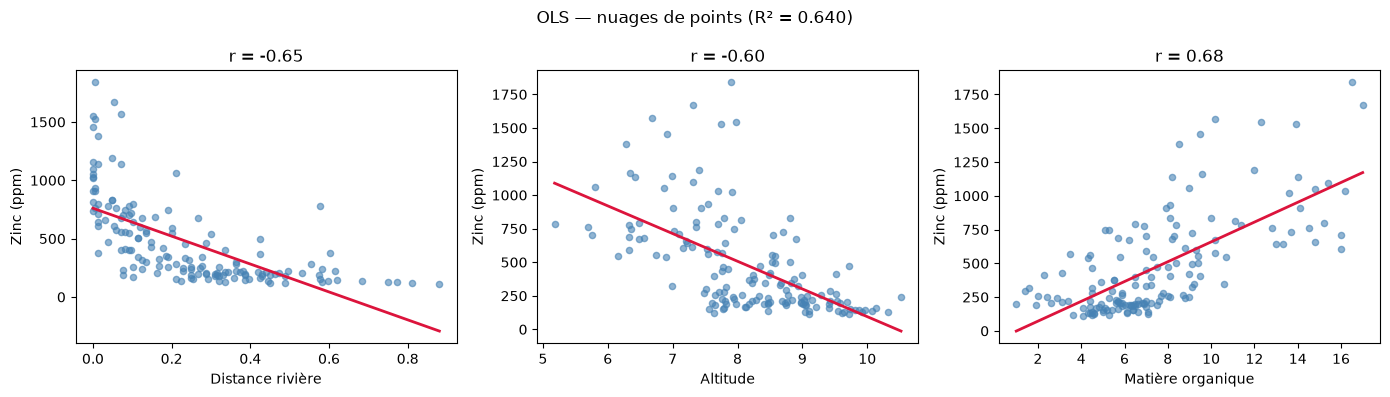

In [10]:
ols = smf.ols('zinc ~ dist + elev + om', data=meuse).fit()
print(f"OLS — R² = {ols.rsquared:.3f}  |  R² adj. = {ols.rsquared_adj:.3f}\n")
print(ols.summary().tables[1])

# Nuages de points de chaque prédicteur vs cible
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
from scipy.stats import pearsonr
for ax, feat, label in zip(axes, features, labels):
    x = meuse[feat].values
    r_val, _ = pearsonr(x, y)
    ax.scatter(x, y, s=20, alpha=0.6, color='steelblue')
    m, b = np.polyfit(x, y, 1)
    ax.plot(np.sort(x), m * np.sort(x) + b, color='crimson', linewidth=2)
    ax.set_xlabel(label.replace('\n', ' '))
    ax.set_ylabel('Zinc (ppm)')
    ax.set_title(f'r = {r_val:.2f}')

plt.suptitle(f"OLS — nuages de points (R² = {ols.rsquared:.3f})", fontsize=12)
plt.tight_layout()
plt.show()


### 4.3 Régression polynomiale

La régression polynomiale remplace la droite $\hat{y} = \beta_0 + \beta_1 x$ par un polynôme

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

Malgré son nom, c'est toujours un modèle linéaire au sens statistique : linéaire par rapport aux paramètres $\beta_j$ (on l'ajuste avec `np.polyfit`, ou une régression OLS sur les colonnes $x, x^2, \ldots, x^d$). Seule la relation entre $x$ et $y$ devient non-linéaire.

Le degré $d$ contrôle la flexibilité. Ici, la relation `zinc ~ dist` est réellement courbée : le zinc décroît vite près de la rivière puis se stabilise (décroissance de type distance-décroissance). C'est le cas idéal pour voir les deux faces du polynôme :

- une droite (degré 1) sous-ajuste — elle rate la courbure et laisse une structure nette dans les résidus ;
- un polynôme de degré modéré (2–3) épouse la courbure et améliore la prédiction hors-échantillon — c'est le vrai intérêt du polynôme, celui qu'une droite ne peut pas offrir ;
- un degré élevé (8) sur-ajuste : il oscille pour coller au bruit et généralise moins bien qu'une droite.

On l'illustre en ajustant sur un petit échantillon de 40 sites (pour rendre le surapprentissage visible) et en évaluant sur les 113 restants, jamais vus lors de l'ajustement.


Degré     R² (entraînement, n=40)   R² (reste, jamais vu)   
1         0.374                     0.422                   
2         0.512                     0.558                   
8         0.576                     -4.444                  
3 (réf.)  0.552                     0.612                   


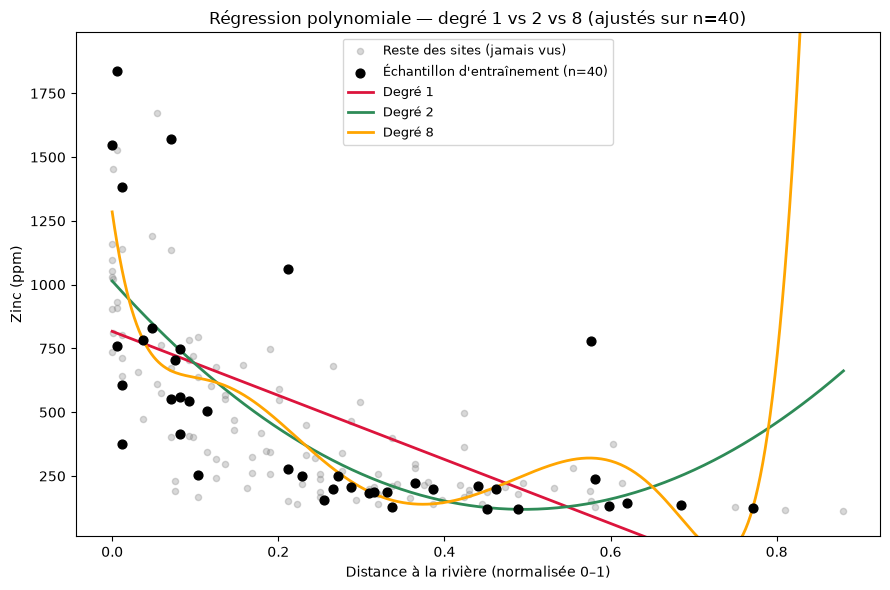


La droite (degré 1) sous-ajuste : elle rate la décroissance courbée du zinc.
Le degré 2 épouse cette courbure et AMÉLIORE le R² hors-échantillon — le vrai
intérêt du polynôme, qu'une droite ne peut pas offrir (le degré 3 n'ajoute
presque plus rien : le gain plafonne). Le degré 8, lui, oscille pour coller au
bruit des 40 points : son R² hors-échantillon s'effondre. La flexibilité utile
a une limite — on choisira le bon degré par validation (§4.7), jamais à l'œil.


In [11]:
x_d = meuse['dist'].values
y_z = meuse['zinc'].values

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(x_d), size=40, replace=False)
rest_idx   = np.setdiff1d(np.arange(len(x_d)), sample_idx)
x_tr, y_tr = x_d[sample_idx], y_z[sample_idx]
x_te, y_te = x_d[rest_idx],   y_z[rest_idx]

x_line = np.linspace(x_d.min(), x_d.max(), 300)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x_te, y_te, alpha=0.3, s=20, color='grey', label='Reste des sites (jamais vus)')
ax.scatter(x_tr, y_tr, s=40, color='black', zorder=5, label="Échantillon d'entraînement (n=40)")

print(f"{'Degré':<10}{'R² (entraînement, n=40)':<26}{'R² (reste, jamais vu)':<24}")
for deg, color in zip([1, 2, 8], ['crimson', 'seagreen', 'orange']):
    coeffs = np.polyfit(x_tr, y_tr, deg)
    ax.plot(x_line, np.polyval(coeffs, x_line), color=color, linewidth=2, label=f'Degré {deg}')
    r2_tr = r2_score(y_tr, np.polyval(coeffs, x_tr))
    r2_te = r2_score(y_te, np.polyval(coeffs, x_te))
    print(f"{deg:<10}{r2_tr:<26.3f}{r2_te:<24.3f}")
# degré 3 (non tracé) — montre que le gain plafonne vite
c3 = np.polyfit(x_tr, y_tr, 3)
print(f"{'3 (réf.)':<10}{r2_score(y_tr, np.polyval(c3, x_tr)):<26.3f}{r2_score(y_te, np.polyval(c3, x_te)):<24.3f}")

ax.set_ylim(y_z.min() - 100, y_z.max() + 150)   # les oscillations du degré 8 sortent du cadre
ax.set_xlabel('Distance à la rivière (normalisée 0–1)'); ax.set_ylabel('Zinc (ppm)')
ax.legend(fontsize=9)
ax.set_title('Régression polynomiale — degré 1 vs 2 vs 8 (ajustés sur n=40)')
plt.tight_layout()
plt.show()

print("\nLa droite (degré 1) sous-ajuste : elle rate la décroissance courbée du zinc.")
print("Le degré 2 épouse cette courbure et AMÉLIORE le R² hors-échantillon — le vrai")
print("intérêt du polynôme, qu'une droite ne peut pas offrir (le degré 3 n'ajoute")
print("presque plus rien : le gain plafonne). Le degré 8, lui, oscille pour coller au")
print("bruit des 40 points : son R² hors-échantillon s'effondre. La flexibilité utile")
print("a une limite — on choisira le bon degré par validation (§4.7), jamais à l'œil.")


### 4.4 GLM — un modèle adapté à une grandeur positive

`zinc` est une concentration : elle est strictement positive par nature. Rien ne garantit pourtant qu'une droite OLS y reste positive. Pire, ici elle ne l'est même pas sur les données observées : la droite `zinc ~ dist` croise zéro dès `dist` ≈ 0.63 et prédit donc des concentrations négatives pour les sites les plus éloignés de la rivière — ce qui n'a aucun sens physique.

Un **GLM** (*Generalized Linear Model*) règle ce problème en ne modélisant plus directement le zinc, mais une transformation de celui-ci. Avec le lien log et une loi Gamma (adaptée à une grandeur positive continue), on modélise :

$$\ln\!\big(\mathbb{E}[\text{zinc}]\big) = \beta_0 + \beta_1 \cdot \text{dist} + \beta_2 \cdot \text{elev} + \beta_3 \cdot \text{om}$$

Le membre de gauche — le *log* de la moyenne prédite — peut prendre n'importe quelle valeur réelle, donc la combinaison linéaire à droite s'ajuste comme dans un OLS. Mais dès qu'on inverse le lien pour revenir à l'échelle du zinc ($\exp(\cdot)$), le résultat est mathématiquement garanti positif, quels que soient les prédicteurs.


In [12]:
# GLM Gamma à lien log : zinc strictement positif
glm = smf.glm('zinc ~ dist + elev + om', data=meuse,
              family=sm.families.Gamma(sm.families.links.Log())).fit()

pred_glm_all = glm.predict(meuse)
r2_glm = r2_score(meuse['zinc'], pred_glm_all)
print(f"OLS                  — R² = {ols.rsquared:.3f}")
print(f"GLM Gamma (lien log) — R² = {r2_glm:.3f}\n")

# Le vrai intérêt du GLM : une droite OLS (zinc ~ dist) prédit du zinc NÉGATIF
# pour les sites éloignés de la rivière — le GLM reste positif par construction.
ols_dist = smf.ols('zinc ~ dist', data=meuse).fit()
glm_dist = smf.glm('zinc ~ dist', data=meuse,
                   family=sm.families.Gamma(sm.families.links.Log())).fit()
grille = pd.DataFrame({'dist': [0.6, 0.7, 0.85]})   # valeurs présentes dans les données
print("Prédiction du zinc (ppm) selon la distance à la rivière :")
print(f"{'dist':>6}{'OLS':>12}{'GLM (log)':>14}")
for d in grille['dist']:
    po = ols_dist.predict(pd.DataFrame({'dist': [d]})).iloc[0]
    pg = glm_dist.predict(pd.DataFrame({'dist': [d]})).iloc[0]
    flag = '  ⚠ négatif !' if po < 0 else ''
    print(f"{d:>6}{po:>12.1f}{pg:>14.1f}{flag}")
print("\nLa droite OLS descend sous 0 (impossible pour une concentration) ; le GLM à")
print("lien log reste positif partout — c'est la garantie qu'apporte le lien.")


OLS                  — R² = 0.640
GLM Gamma (lien log) — R² = 0.641

Prédiction du zinc (ppm) selon la distance à la rivière :
  dist         OLS     GLM (log)
   0.6        43.1         157.4
   0.7       -76.5         120.7  ⚠ négatif !
  0.85      -255.9          81.0  ⚠ négatif !

La droite OLS descend sous 0 (impossible pour une concentration) ; le GLM à
lien log reste positif partout — c'est la garantie qu'apporte le lien.


### 4.5 GAM thématique — splines sur les variables de terrain

Un **GAM** remplace la droite de régression de chaque prédicteur par une courbe lisse (B-spline). Cela permet de capturer des relations non-linéaires — par exemple un effet de la distance qui s'atténue au-delà d'un certain seuil.

La pénalité de lissage (`alpha`) contrôle la souplesse de la courbe : plus `alpha` est grand, plus la courbe se rapproche d'une droite. En `statsmodels`, le GAM utilise des B-splines pénalisées (P-splines).

Le graphe d'effets partiels (`plot_partial`) montre la contribution de chaque variable à la prédiction, toutes choses égales par ailleurs.


GAM thématique — R² = 0.679  (vs OLS : 0.640)


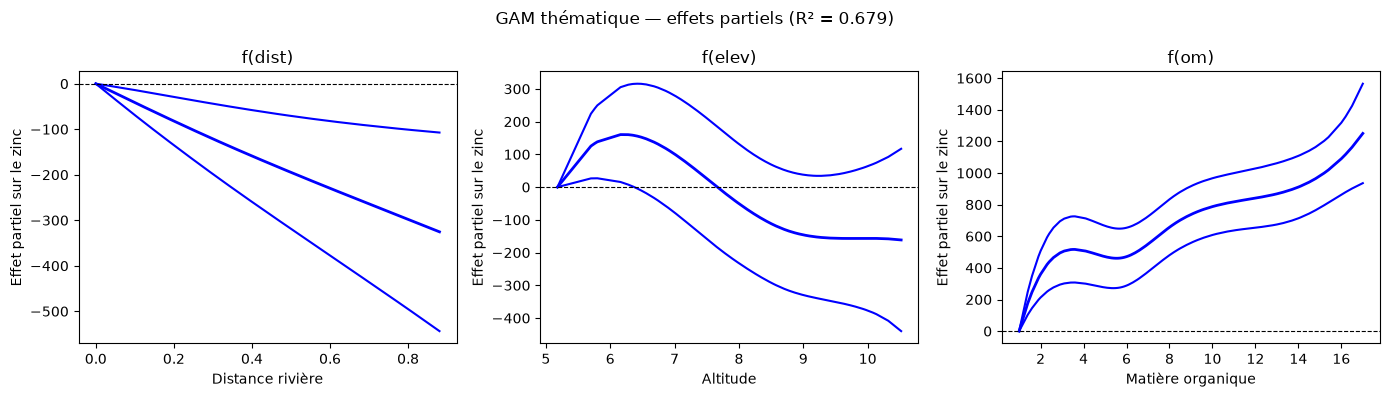

In [13]:
# Base de B-splines pour les 3 variables de terrain
# df=6 : 6 fonctions de base par variable ; degree=3 : splines cubiques
bs_th = BSplines(X_th, df=[6, 6, 6], degree=[3, 3, 3])

# Ajustement du GAM avec pénalité de lissage (alpha = [1, 1, 1])
gam_th = GLMGam(y, smoother=bs_th, alpha=[1, 1, 1]).fit()
r2_gam_th = r2_score(y, gam_th.fittedvalues)
print(f"GAM thématique — R² = {r2_gam_th:.3f}  (vs OLS : {ols.rsquared:.3f})")

# Effets partiels : contribution de chaque variable lisse
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (ax, label) in enumerate(zip(axes, labels)):
    gam_th.plot_partial(i, ax=ax, plot_se=True)
    ax.set_xlabel(label.replace('\n', ' '))
    ax.set_ylabel('Effet partiel sur le zinc')
    ax.set_title(f'f({features[i]})')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')

plt.suptitle(f"GAM thématique — effets partiels (R² = {r2_gam_th:.3f})", fontsize=12)
plt.tight_layout()
plt.show()


### 4.6 GAM spatial, ajouter un lisseur géographique

La carte du zinc (§4.1) montrait un gradient spatial marqué (concentrations élevées le long de la rivière). Une partie de ce gradient n'est pas capturée par les seules variables de terrain.

On l'intègre en ajoutant un lisseur spatial 2D : $f(x, y)$ — une surface lisse sur les coordonnées des sites. Cela revient à modéliser l'autocorrélation spatiale résiduelle.

$$\widehat{\text{zinc}} = \beta_0 + f_1(\text{dist}) + f_2(\text{elev}) + f_3(\text{om}) + f_4(x, y)$$

Le lisseur spatial est ajusté avec une pénalité plus faible (`alpha` plus petit) pour lui permettre de capturer des gradients larges.


OLS               R² = 0.640
GAM thématique    R² = 0.679
GAM spatial       R² = 0.825  ← amélioration due au lisseur géographique


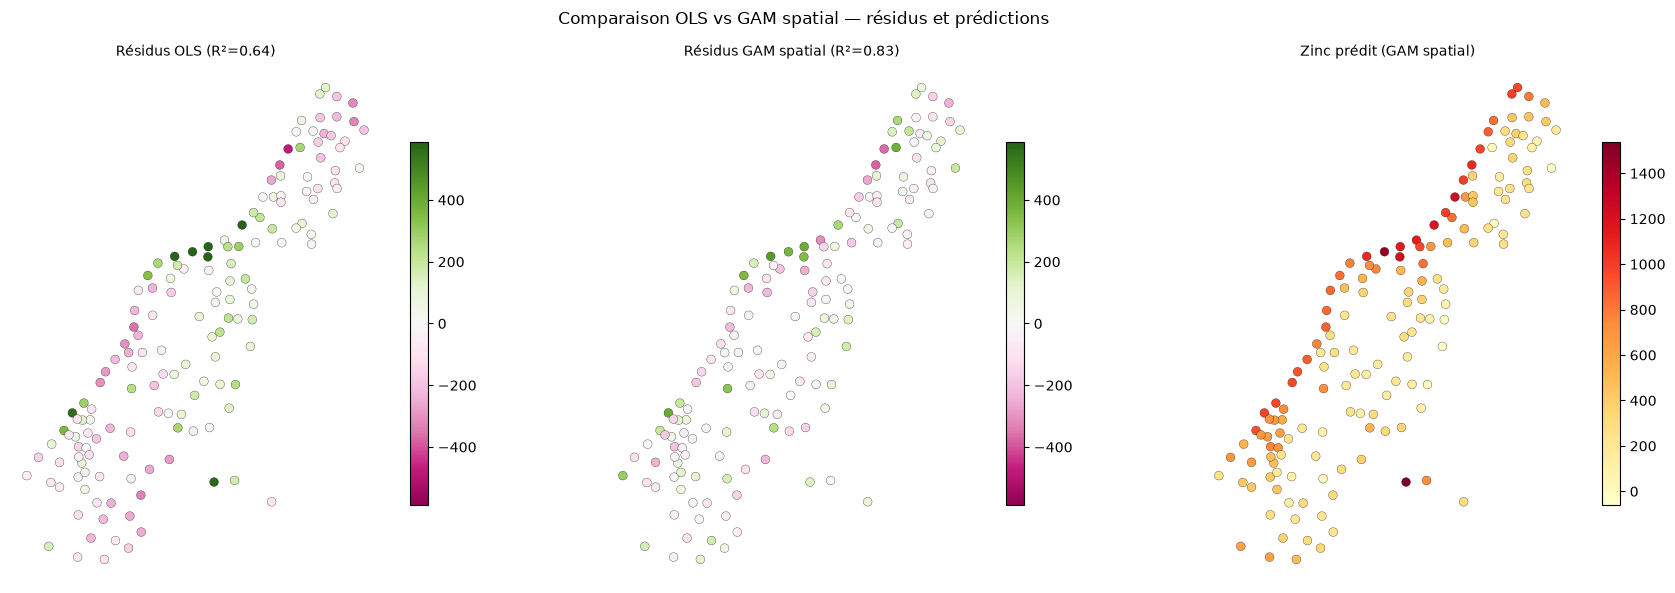

In [14]:
# Base de B-splines : variables de terrain + coordonnées spatiales
# Les coordonnées (x, y) reçoivent plus de fonctions de base (df=8)
# et une pénalité plus faible (alpha=1e-3) pour capturer le gradient spatial
bs_sp = BSplines(X_sp, df=[6, 6, 6, 8, 8], degree=[3, 3, 3, 3, 3])
gam_sp = GLMGam(y, smoother=bs_sp, alpha=[1, 1, 1, 1e-3, 1e-3]).fit()
r2_gam_sp = r2_score(y, gam_sp.fittedvalues)

print(f"OLS               R² = {ols.rsquared:.3f}")
print(f"GAM thématique    R² = {r2_gam_th:.3f}")
print(f"GAM spatial       R² = {r2_gam_sp:.3f}  ← amélioration due au lisseur géographique")

# Résidus OLS vs GAM spatial (cartes de points)
resid_ols = y - ols.predict(meuse).values
resid_gam = y - gam_sp.fittedvalues
pred_gam  = gam_sp.fittedvalues
vabs = np.percentile(np.abs(resid_ols), 97)

xx, yy = meuse['x'].values, meuse['y'].values
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, vals, title, cmap, kw in [
    (axes[0], resid_ols, f'Résidus OLS (R²={ols.rsquared:.2f})',      'PiYG',   dict(vmin=-vabs, vmax=vabs)),
    (axes[1], resid_gam, f'Résidus GAM spatial (R²={r2_gam_sp:.2f})', 'PiYG',   dict(vmin=-vabs, vmax=vabs)),
    (axes[2], pred_gam,  'Zinc prédit (GAM spatial)',                 'YlOrRd', {}),
]:
    sc = ax.scatter(xx, yy, c=vals, cmap=cmap, s=40, edgecolor='k', linewidth=0.2, **kw)
    plt.colorbar(sc, ax=ax, shrink=0.7)
    ax.set_title(title, fontsize=10); ax.set_aspect('equal'); ax.set_axis_off()

plt.suptitle("Comparaison OLS vs GAM spatial — résidus et prédictions", fontsize=12)
plt.tight_layout()
plt.show()


### 4.7 Validation croisée K-fold

Les R² vus jusqu'ici (OLS, polynomiale, GLM, GAM) sont pour la plupart calculés sur les mêmes données que celles utilisées pour l'ajustement : ils sont optimistes. Un modèle plus complexe peut avoir un R² d'entraînement élevé tout en généralisant mal à de nouvelles observations (*surapprentissage*) — on vient de le voir avec le polynôme de degré 8 (§4.3).

La **validation croisée à K plis** (K-fold CV) fournit une estimation honnête, applicable uniformément aux cinq modèles :
1. Diviser les 153 sites en K=5 groupes (*plis*)
2. Pour chaque pli : entraîner sur les 4 autres, évaluer sur celui-ci
3. Moyenner les R² des 5 plis

Pour que la CV fonctionne avec les GAM, on utilise un pipeline sklearn équivalent :
`SplineTransformer` (base B-spline, knots sur quantiles) + `Ridge` (pénalisation L₂ ≈ pénalité de lissage). Le GLM n'a pas de wrapper scikit-learn standard : sa CV est effectuée manuellement, pli par pli, avec `statsmodels`.


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 1. OLS (référence linéaire)
r2_cv_ols = cross_val_score(LinearRegression(), X_th, y, cv=kf, scoring='r2')

# 2. Régression polynomiale (degré 2, sur les 3 variables de terrain)
pipe_poly = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
r2_cv_poly = cross_val_score(pipe_poly, X_th, y, cv=kf, scoring='r2')
r2_poly_train = r2_score(y, pipe_poly.fit(X_th, y).predict(X_th))

# 3. GLM (Gamma, lien log) — pas de wrapper scikit-learn standard : CV manuelle
r2_cv_glm = []
for tr_idx, te_idx in kf.split(X_th):
    train_df, test_df = meuse.iloc[tr_idx], meuse.iloc[te_idx]
    glm_fold = smf.glm('zinc ~ dist + elev + om', data=train_df,
                       family=sm.families.Gamma(sm.families.links.Log())).fit()
    pred_fold = glm_fold.predict(test_df)
    r2_cv_glm.append(r2_score(test_df['zinc'], pred_fold))
r2_cv_glm = np.array(r2_cv_glm)

# 4. GAM thématique ≈ SplineTransformer + Ridge (pénalité L2 ≈ pénalité de lissage)
pipe_th = make_pipeline(
    SplineTransformer(n_knots=5, degree=3, knots='quantile'),
    Ridge(alpha=10)
)
r2_cv_gam_th = cross_val_score(pipe_th, X_th, y, cv=kf, scoring='r2')

# 5. GAM spatial ≈ SplineTransformer + Ridge sur [terrain + x, y]
pipe_sp = make_pipeline(
    SplineTransformer(n_knots=5, degree=3, knots='quantile'),
    Ridge(alpha=0.1)
)
r2_cv_gam_sp = cross_val_score(pipe_sp, X_sp, y, cv=kf, scoring='r2')

# Tableau récapitulatif
results = pd.DataFrame({
    'Modèle':          ['OLS', 'Polynomial (deg. 2)', 'GLM (Gamma, log)', 'GAM thématique', 'GAM spatial'],
    'R² entraînement': [ols.rsquared, r2_poly_train, r2_glm, r2_gam_th, r2_gam_sp],
    'R² CV (5-fold)':  [r2_cv_ols.mean(), r2_cv_poly.mean(), r2_cv_glm.mean(), r2_cv_gam_th.mean(), r2_cv_gam_sp.mean()],
    '± (écart-type)':  [r2_cv_ols.std(),  r2_cv_poly.std(),  r2_cv_glm.std(),  r2_cv_gam_th.std(),  r2_cv_gam_sp.std()],
}).round(3)

print(results.to_string(index=False))
print()
print("✓ Polynomial / GAM thématique : captent la courbure de `dist` → gain net sur OLS.")
print("✓ GLM : garde des prédictions positives, sans complexité supplémentaire majeure.")
print("✓ GAM spatial : R² CV le plus élevé → le gradient géographique (proximité de la")
print("  rivière) est un signal réel et généralisable, pas un artefact de l'échantillon.")


             Modèle  R² entraînement  R² CV (5-fold)  ± (écart-type)
                OLS            0.640           0.589           0.103
Polynomial (deg. 2)            0.707           0.588           0.093
   GLM (Gamma, log)            0.641           0.580           0.181
     GAM thématique            0.679           0.621           0.024
        GAM spatial            0.825           0.741           0.038

✓ Polynomial / GAM thématique : captent la courbure de `dist` → gain net sur OLS.
✓ GLM : garde des prédictions positives, sans complexité supplémentaire majeure.
✓ GAM spatial : R² CV le plus élevé → le gradient géographique (proximité de la
  rivière) est un signal réel et généralisable, pas un artefact de l'échantillon.


### 4.8 Incertitude liée au découpage — validation croisée répétée

Le tableau précédent donne une seule valeur de R² CV par modèle — celle obtenue avec `random_state=42`. Mais avec seulement 153 sites, répartis aléatoirement en 5 plis de ~31 observations, le découpage lui-même est une source de variabilité : un autre tirage donnerait un R² CV légèrement différent, simplement parce que les plis contiendraient des sites différents.

On répète la validation croisée 20 fois, avec un `random_state` différent à chaque fois, pour visualiser la distribution du R² CV plutôt qu'un seul chiffre. Plus le jeu de données est petit, plus cette variabilité est grande — un avertissement à garder en tête chaque fois qu'on compare deux R² CV calculés une seule fois.

> ⚠️ Ce n'est pas du bootstrap, même si les deux techniques « répètent une procédure aléatoire plusieurs fois » : ici, on ré-utilise toujours les 153 mêmes sites, seul le *découpage* en plis change. Le bootstrap (§4.9) tire un nouvel échantillon de sites à chaque répétition — une question différente.


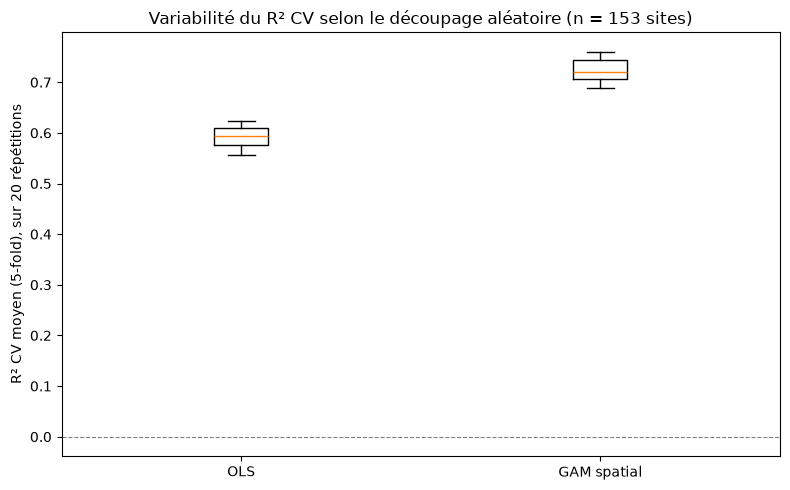

OLS         : R² CV = 0.594 ± 0.019  (plage 0.557 – 0.623)
GAM spatial : R² CV = 0.725 ± 0.022  (plage 0.690 – 0.761)

Le R² CV varie d'un tirage à l'autre, d'autant plus que n est petit (153 sites).
Le GAM spatial reste nettement au-dessus de l'OLS sur tous les tirages : son
avantage (le gradient géographique) est robuste au découpage, pas un coup de chance
d'un seul essai.


In [17]:
n_repeats = 20
r2_repeats_ols    = []
r2_repeats_gam_sp = []
for seed in range(n_repeats):
    kf_r = KFold(n_splits=5, shuffle=True, random_state=seed)
    r2_repeats_ols.append(cross_val_score(LinearRegression(), X_th, y, cv=kf_r, scoring='r2').mean())
    r2_repeats_gam_sp.append(cross_val_score(pipe_sp, X_sp, y, cv=kf_r, scoring='r2').mean())

r2_repeats_ols    = np.array(r2_repeats_ols)
r2_repeats_gam_sp = np.array(r2_repeats_gam_sp)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([r2_repeats_ols, r2_repeats_gam_sp], tick_labels=['OLS', 'GAM spatial'])
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_ylabel(f'R² CV moyen (5-fold), sur {n_repeats} répétitions')
ax.set_title(f'Variabilité du R² CV selon le découpage aléatoire (n = {len(y)} sites)')
plt.tight_layout()
plt.show()

print(f"OLS         : R² CV = {r2_repeats_ols.mean():.3f} ± {r2_repeats_ols.std():.3f}  "
      f"(plage {r2_repeats_ols.min():.3f} – {r2_repeats_ols.max():.3f})")
print(f"GAM spatial : R² CV = {r2_repeats_gam_sp.mean():.3f} ± {r2_repeats_gam_sp.std():.3f}  "
      f"(plage {r2_repeats_gam_sp.min():.3f} – {r2_repeats_gam_sp.max():.3f})")
print()
print("Le R² CV varie d'un tirage à l'autre, d'autant plus que n est petit (153 sites).")
print("Le GAM spatial reste nettement au-dessus de l'OLS sur tous les tirages : son")
print("avantage (le gradient géographique) est robuste au découpage, pas un coup de chance")
print("d'un seul essai.")


### 4.9 Bootstrap, intervalle de confiance par ré-échantillonnage

La CV répétée (§4.8) fait varier le découpage en plis, mais utilise toujours les mêmes 153 sites. Le **bootstrap** répond à une question différente : si on avait observé un *autre échantillon* de sites dans la plaine de la Meuse (même processus, tirage différent), quelle serait la variabilité du R² ?

Le principe : tirer, $B$ fois, un nouvel échantillon de 153 sites avec remise depuis les données observées (certains sites apparaissent plusieurs fois, d'autres pas du tout), ré-ajuster le modèle sur chaque tirage, et regarder la distribution des R² obtenus. Pour que chaque réplication reste une évaluation hors échantillon (et non optimiste comme un R² d'entraînement), on évalue chaque modèle sur les sites jamais tirés dans cette réplication: les points *out-of-bag* (OOB), qui représentent en moyenne environ 37 % de l'échantillon original.

> Bootstrap et CV répétée sont deux outils complémentaires, pas concurrents, pour quantifier l'incertitude d'un R² : la CV répétée mesure l'incertitude due au découpage train/test ; le bootstrap mesure l'incertitude due à l'échantillonnage de la population source. Dans un projet réel, les deux questions sont légitimes, et rien n'empêche de les utiliser ensemble.


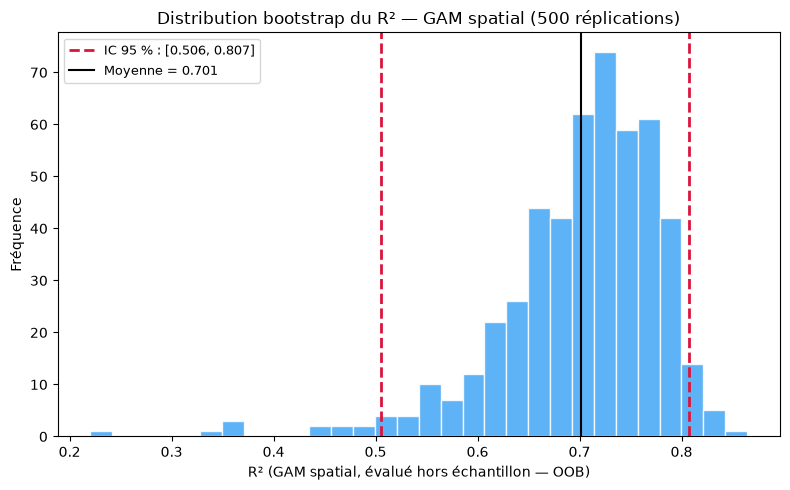

R² bootstrap (OOB) : moyenne = 0.701  écart-type = 0.079
Intervalle de confiance à 95 % : [0.506, 0.807]

Le bootstrap inclut l'incertitude due au fait que nos 153 sites ne sont eux-mêmes
qu'UN échantillon parmi d'autres possibles, une source de variabilité que la CV
répétée (qui réutilise toujours les mêmes 153 sites) ne capture pas.


In [19]:
n_boot = 500
n = len(meuse)
rng_boot = np.random.default_rng(1)

r2_boot = []
for _ in range(n_boot):
    boot_idx = rng_boot.integers(0, n, size=n)          # tirage avec remise (même taille que l'original)
    oob_idx  = np.setdiff1d(np.arange(n), boot_idx)     # sites jamais tirés (hors échantillon)
    if len(oob_idx) < 5:
        continue   # cas rare : trop peu de points OOB pour évaluer

    pipe_boot = make_pipeline(SplineTransformer(n_knots=5, degree=3, knots='quantile'), Ridge(alpha=0.1))
    pipe_boot.fit(X_sp[boot_idx], y[boot_idx])
    r2_boot.append(r2_score(y[oob_idx], pipe_boot.predict(X_sp[oob_idx])))

r2_boot = np.array(r2_boot)
ci_low, ci_high = np.percentile(r2_boot, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(r2_boot, bins=30, color='#42a5f5', alpha=0.85, edgecolor='white')
ax.axvline(ci_low,  color='crimson', linestyle='--', linewidth=2)
ax.axvline(ci_high, color='crimson', linestyle='--', linewidth=2,
           label=f'IC 95 % : [{ci_low:.3f}, {ci_high:.3f}]')
ax.axvline(r2_boot.mean(), color='black', linewidth=1.5, label=f'Moyenne = {r2_boot.mean():.3f}')
ax.set_xlabel('R² (GAM spatial, évalué hors échantillon — OOB)')
ax.set_ylabel('Fréquence')
ax.set_title(f'Distribution bootstrap du R² — GAM spatial ({len(r2_boot)} réplications)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"R² bootstrap (OOB) : moyenne = {r2_boot.mean():.3f}  écart-type = {r2_boot.std():.3f}")
print(f"Intervalle de confiance à 95 % : [{ci_low:.3f}, {ci_high:.3f}]")
print()
print("Le bootstrap inclut l'incertitude due au fait que nos 153 sites ne sont eux-mêmes")
print("qu'UN échantillon parmi d'autres possibles, une source de variabilité que la CV")
print("répétée (qui réutilise toujours les mêmes 153 sites) ne capture pas.")


---
## Récapitulatif

### Parties 1–3 : Géotraitement vectoriel (parallèle du TP QGIS 3)

| Opération QGIS | Code Python clé |
|---|---|
| Sélection par expression | `gdf[gdf['col'].str.contains(...)]` |
| Fusionner (dissolve) | `gdf.dissolve()` |
| Couper (Clip) | `gpd.clip(layer, mask)` |
| Zone tampon (Buffer) | `.buffer(dist)` + `.union_all()` |
| Double buffer (ZDB) | `.buffer(+75).union_all()` puis `.buffer(-75)` |
| Union / Différence / Intersection | `geom_a.union/difference/intersection(geom_b)` |

### Partie 4 : Régression non-linéaire : polynômes, GLM et GAM (jeu **Meuse**)

| Étape | Code clé |
|---|---|
| Charger données + points | `pd.read_csv('meuse.csv')` + `gpd.points_from_xy(x, y)` |
| Baseline OLS | `smf.ols('zinc ~ dist + elev + om', data=meuse).fit()` |
| Régression polynomiale | `np.polyfit(x, y, deg=d)` / `PolynomialFeatures(degree=d)` |
| GLM (Gamma, lien log) | `smf.glm('zinc ~ ...', family=sm.families.Gamma(sm.families.links.Log())).fit()` |
| Base B-splines | `BSplines(X, df=[6,6,6], degree=[3,3,3])` |
| Ajuster GAM | `GLMGam(y, smoother=bs, alpha=[1,1,1]).fit()` |
| Effets partiels | `gam.plot_partial(i, ax=ax, plot_se=True)` |
| Lisseur spatial | ajouter `x, y` à la base B-splines, `alpha` plus faible |
| Validation croisée | `cross_val_score(pipe, X, y, cv=KFold(5), scoring='r2')` |
| CV répétée (incertitude du découpage) | répéter la CV avec plusieurs `random_state` |
| Bootstrap OOB (incertitude d'échantillonnage) | tirage avec remise + évaluation sur les points jamais tirés |

Concepts clés :

| Concept | Signification |
|---|---|
| **R² entraînement** | Mesuré sur les mêmes données → toujours optimiste |
| **R² CV (5-fold)** | Estimation honnête de la généralisation, elle-même incertaine (§4.8) |
| **Surapprentissage** | R² train ≫ R² CV → modèle trop complexe pour les données |
| **Lien (GLM)** | Transformation (ici log) qui garantit des prédictions valides — ici toujours $> 0$ |
| **Lisseur spatial** | $f(x, y)$ capte l'autocorrélation spatiale résiduelle (gradient de la rivière) |
| **Effet partiel** | Contribution de $f_j(x_j)$ à $\hat{y}$, toutes choses égales par ailleurs |

### 🎯 Bonnes pratiques ML : comparer et quantifier

| Principe | Où on l'a vu |
|---|---|
| Le choix du modèle commence par le type de la cible (continu / positif-borné / catégoriel) | §4 (tableau de décision) |
| Comparer plusieurs modèles candidats avec la même procédure d'évaluation (K-fold CV) | §4.7 |
| La flexibilité d'un modèle n'est pas gratuite : plus de paramètres libres augmente le risque de surapprentissage, sauf si les données le justifient (ici, une vraie courbure) | §4.3, §4.5 vs §4.6 |
| Une estimation de performance a elle-même une incertitude — répéter la CV et/ou utiliser le bootstrap avant de conclure | §4.8–4.9 |

> **Règle clé** : le R² d'entraînement ne dit pas si le modèle généralisera, et un R² CV calculé une seule fois n'est lui-même qu'une estimation bruitée (§4.8) — le bootstrap (§4.9) en donne une seconde estimation, généralement plus large. Le GAM spatial capture un effet géographique réel (le gradient de la rivière) qui reste robuste en validation croisée.
